<a href="https://colab.research.google.com/github/sauravk21/cv_tutorial/blob/main/Image_Quality_(Maniqa).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics
!pip install pyiqa
!pip install opencv-python
!pip install torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 12.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256

In [3]:
import cv2
import torch
from ultralytics import YOLO
import pyiqa


# --------------------------------------------------
# Load Models
# --------------------------------------------------

# Nano model (very small)
detector = YOLO("yolov8n.pt")

# Image Quality Assessment model
quality_model = pyiqa.create_metric("maniqa")

# --------------------------------------------------
# Detect Largest Person
# --------------------------------------------------

def detect_person(image):

    results = detector(image, verbose=False)

    persons = []

    for box in results[0].boxes:

        cls = int(box.cls)

        # COCO class 0 = person
        if cls != 0:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        area = (x2 - x1) * (y2 - y1)

        persons.append((area, x1, y1, x2, y2))

    if len(persons) == 0:
        return None

    persons.sort(reverse=True)

    _, x1, y1, x2, y2 = persons[0]

    return image[y1:y2, x1:x2]


# --------------------------------------------------
# Predict Image Quality
# --------------------------------------------------

def quality_score(person_crop):

    rgb = cv2.cvtColor(person_crop, cv2.COLOR_BGR2RGB)

    tensor = torch.from_numpy(rgb).float() / 255.0

    tensor = tensor.permute(2,0,1).unsqueeze(0)

    score = quality_model(tensor)

    return score.item()


# --------------------------------------------------
# Pipeline
# --------------------------------------------------

def evaluate_image(path):

    image = cv2.imread(path)

    if image is None:
        print("Cannot read image")
        return

    person = detect_person(image)

    if person is None:
        print("No person detected")
        return

    score = quality_score(person)

    print(f"Quality Score : {score:.3f}")


# --------------------------------------------------



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/ckpt_koniq10k.pt" to /root/.cache/torch/hub/pyiqa/ckpt_koniq10k.pt



100%|██████████| 518M/518M [00:10<00:00, 50.4MB/s]


Loading pretrained model MANIQA from /root/.cache/torch/hub/pyiqa/ckpt_koniq10k.pt
Quality Score : 0.320
BAD PHOTO


In [15]:
from pathlib import Path
from PIL import Image
from IPython.display import display

Image path: /content/WhatsApp Image 2026-06-29 at 23.09.01.jpeg


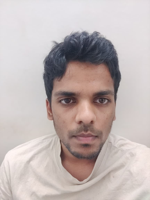

Quality Score : 0.449
BAD PHOTO


In [16]:
image_path = Path("/content/WhatsApp Image 2026-06-29 at 23.09.01.jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)

evaluate_image("/content/WhatsApp Image 2026-06-29 at 23.09.01.jpeg")

Image path: /content/WhatsApp Image 2025-03-13 at 5.55.07 PM.jpeg


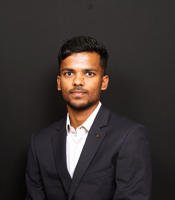

Quality Score : 0.415
BAD PHOTO


In [17]:
image_path = Path("/content/WhatsApp Image 2025-03-13 at 5.55.07 PM.jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)



evaluate_image("/content/WhatsApp Image 2025-03-13 at 5.55.07 PM.jpeg")

Image path: /content/WhatsApp Image 2025-04-05 at 11.13.07 AM.jpeg


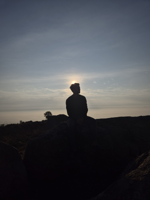

Quality Score : 0.320
BAD PHOTO


In [18]:
image_path = Path("/content/WhatsApp Image 2025-04-05 at 11.13.07 AM.jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)



evaluate_image("/content/WhatsApp Image 2025-04-05 at 11.13.07 AM.jpeg")

Image path: /content/WhatsApp Image 2026-06-29 at 23.01.39 (1).jpeg


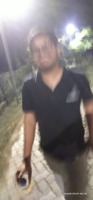

Quality Score : 0.092
BAD PHOTO


In [19]:
image_path = Path("/content/WhatsApp Image 2026-06-29 at 23.01.39 (1).jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)



evaluate_image("/content/WhatsApp Image 2026-06-29 at 23.01.39 (1).jpeg")

Image path: /content/WhatsApp Image 2026-06-29 at 23.01.40.jpeg


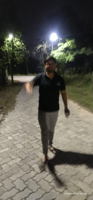

Quality Score : 0.113
BAD PHOTO


In [20]:
image_path = Path("/content/WhatsApp Image 2026-06-29 at 23.01.40.jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)


evaluate_image("/content/WhatsApp Image 2026-06-29 at 23.01.40.jpeg")

Image path: /content/WhatsApp Image 2026-06-29 at 23.01.41.jpeg


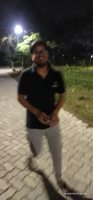

Quality Score : 0.071
BAD PHOTO


In [21]:
image_path = Path("/content/WhatsApp Image 2026-06-29 at 23.01.41.jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)


evaluate_image("/content/WhatsApp Image 2026-06-29 at 23.01.41.jpeg")

Image path: /content/WhatsApp Image 2026-06-29 at 23.29.57.jpeg


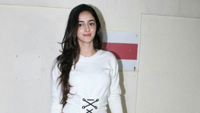

Quality Score : 0.310
BAD PHOTO


In [22]:
#Ananya Pandey
image_path = Path("/content/WhatsApp Image 2026-06-29 at 23.29.57.jpeg")

image = Image.open(image_path)
image.thumbnail((200, 200))

print(f"Image path: {image_path}")
display(image)


evaluate_image("/content/WhatsApp Image 2026-06-29 at 23.29.57.jpeg")

Image path: /content/WhatsApp Image 2026-06-29 at 23.29.57 (1).jpeg


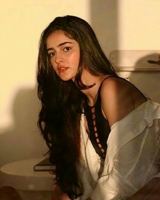

Quality Score : 0.302
BAD PHOTO


In [23]:
#Ananya Pandey 2
image_path = Path("/content/WhatsApp Image 2026-06-29 at 23.29.57 (1).jpeg")
image = Image.open(image_path)
image.thumbnail((200, 200))
print(f"Image path: {image_path}")
display(image)


evaluate_image("/content/WhatsApp Image 2026-06-29 at 23.29.57 (1).jpeg")